# ICLR 2027 submission figures

Every figure in the paper is built here, from the wandb sweeps and the runs logged under `MICE/`.
Run from `MICE/figs/` with the `omnisafe` env (`/home/kaustubh/anaconda3/envs/omnisafe/bin/python`).

The notebook is in two halves. **Toolkit** is the reusable part -- pulling a sweep, scoring and
picking configs, building mean +/- SEM bands over seeds, and drawing a row of panels; nothing in it
knows about any particular figure. **Figures** is one short cell per figure that calls into it.
Adding figure 2 should mean writing a `Panel` list and a `series` dict, not another plotting
routine.

## Toolkit

### Setup and house style

In [ ]:
from __future__ import annotations

import re
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, MaxNLocator, NullFormatter

HERE = Path.cwd()                 # MICE/figs
MICE = HERE.parent
DATA = MICE / "analysis_data"
PROJECT = "liam-paull/calibration_rl"

# Authored at the ICLR text width -- a single-column template, so this is also the widest a figure
# can be placed. Sizing to it means \includegraphics[width=\textwidth] scales by 1.0 and every font
# comes out the size it is set to here; authoring wider and letting LaTeX shrink the figure is what
# turns tick labels to mush.
TEXTWIDTH = 5.5

# Categorical slots 1 and 2 of the house palette, in slot order, validated as a pair for CVD and
# normal-vision separation on a light surface. Extend in slot order; never cycle.
SLOTS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, MUTED, GRID, RULE = "#0e1418", "#7b8792", "#dce2e7", "#b9c2ca"

# Paper-facing names. The data keeps wandb's own algo strings as the join key; this is only what
# the figures print.
ALGO_LABEL = {"TRPOPID": "PIDLag"}


def label_of(algo: str) -> str:
    return ALGO_LABEL.get(algo, algo)

plt.rcParams.update({
    "figure.figsize": (TEXTWIDTH, 2.0),   # the page-width default; plot_panels reads it
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 13,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "axes.labelcolor": MUTED,
    "axes.edgecolor": GRID,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.frameon": False,
    "legend.fontsize": 20,
    "lines.linewidth": 1.4,
    "pdf.fonttype": 42,           # TrueType, not Type 3 -- the submission checker rejects Type 3
    "ps.fonttype": 42,
})


def save_fig(fig, stem: str, *, pad: float = 0.02) -> None:
    """Vector PDF for LaTeX, 300 dpi PNG for looking at, both next to this notebook."""
    for ext, kw in (("pdf", {}), ("png", {"dpi": 400})):
        out = HERE / f"{stem}.{ext}"
        fig.savefig(out, bbox_inches="tight", pad_inches=pad, facecolor="white", **kw)
        print(f"wrote {out.name}  ({out.stat().st_size / 1024:.0f} KB)")


def steps_fmt(ax) -> None:
    """Env-step ticks that read 5M, not 5000000."""
    ax.xaxis.set_major_formatter(FuncFormatter(
        lambda v, _: f"{v/1e6:g}M" if v >= 1e6 else (f"{v/1e3:g}k" if v >= 1e3 else f"{v:g}")))

### Pulling a sweep

`load_sweep` caches to `analysis_data/sweep_<id>/history.csv.gz` and only calls wandb when the cache
is missing, so re-running the notebook is offline and fast. Per-run config comes from
`run.metadata["args"]` -- the sweep agent's command line -- because these runs have an empty
`run.config` on wandb, leaving the command line as the only record of which grid point a run is.

`CONFIG_ARGS` maps the sweep's flags onto the frame's config columns. A different sweep varying
different flags means a different mapping passed in, not an edit here.

In [ ]:
DEFAULT_KEYS = ["TotalEnvSteps", "Metrics/EpRet", "Metrics/EpCost", "Metrics/TotalCost",
                "PooledMC/Correlation_r", "PooledMC/Correlation_c"]

# column -> (cli flag, caster). The columns named here become the config identity of a run.
CONFIG_ARGS = {
    "algo":         ("algo", str),
    "seed":         ("seed", int),
    "adv":          ("adv-estimation-method", str),
    "update_iters": ("algo-cfgs.update-iters", int),
    "critic_lr":    ("model-cfgs.critic.lr", float),
    "cost_limit":   ("cost-limit", float),
}
CFG = ["algo", "adv", "update_iters", "critic_lr"]     # what identifies a grid point, minus seed


def pull_sweep(sweep: str, *, project: str = PROJECT, keys: list[str] = DEFAULT_KEYS,
               config_args: dict = CONFIG_ARGS, max_workers: int = 10) -> pd.DataFrame:
    """Every run in a sweep as one long-form frame: history columns plus config columns.

    Each run is a handful of small, independent network calls, so this is I/O-bound -- a thread
    pool, not a process pool, and 10 workers turns 80 sequential pulls into about one pull's
    wall clock.
    """
    import wandb

    def one(run_id: str) -> pd.DataFrame:
        run = wandb.Api(timeout=90).run(f"{project}/{run_id}")   # Api is not documented thread-safe
        args = dict(m.groups() for a in (run.metadata or {}).get("args", [])
                    if (m := re.match(r"^--([^=]+)=(.*)$", a)))
        h = run.history(keys=keys, pandas=True, samples=100_000)
        for c in h.columns:                       # wandb hands these back as object columns
            h[c] = pd.to_numeric(h[c], errors="coerce")
        h = h.sort_values("TotalEnvSteps").reset_index(drop=True)
        cfg = {col: (cast(args[flag]) if flag in args else None)
               for col, (flag, cast) in config_args.items()}
        return h.assign(run_id=run_id, **cfg)

    ids = [r.id for r in wandb.Api(timeout=90).sweep(f"{project}/{sweep}").runs]
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futs = [pool.submit(one, rid) for rid in ids]
        return pd.concat([f.result() for f in as_completed(futs)], ignore_index=True)


def load_sweep(sweep: str, *, refresh: bool = False, **pull_kw) -> pd.DataFrame:
    """Cached `pull_sweep`. Pass refresh=True to re-pull a sweep that has since gained runs."""
    cache = DATA / f"sweep_{sweep}" / "history.csv.gz"
    if cache.exists() and not refresh:
        print(f"cache: {cache.relative_to(MICE)}")
        return pd.read_csv(cache)
    df = pull_sweep(sweep, **pull_kw)
    cache.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(cache, index=False)
    print(f"pulled {df.run_id.nunique()} runs -> {cache.relative_to(MICE)}")
    return df

### Scoring configs and picking a winner

Each run is reduced to one number and configs are ranked by that number averaged over their 5 seeds.
`BASIS` below picks what the number is:

| basis | score | best is |
|---|---|---|
| `"ratio"` | mean `EpRet` over the last 10% of training / final `Metrics/TotalCost` | highest |
| `"ret"` | mean `EpRet` over the last 10% of training | highest |
| `"cost"` | final `Metrics/TotalCost`, the cumulative cost paid over the run | lowest |

`ratio` asks what return was bought per unit of cost paid, `ret` ignores cost entirely, and `cost`
ignores return -- so `cost` will happily crown a config that learned nothing, and is there to be
read next to the others rather than alone. The tail window means the score reads final policy
quality rather than how fast the run got there; `TAIL_FRAC` is the knob.

To rank on something else, pass a `Score(fn, higher_is_better, label)` of your own as `basis` --
nothing downstream sees anything but the resulting column.

In [ ]:
@dataclass(frozen=True)
class Score:
    """A basis for ranking configs: how to reduce a run to a number, and which end is better."""
    fn: callable                          # (run_frame, tail_frame) -> float
    higher_is_better: bool
    label: str


# The bases you can rank on. `tail` is the last TAIL_FRAC of the run, `g` the whole run.
SCORES = {
    "ratio": Score(lambda g, tail: tail["Metrics/EpRet"].mean() / g["Metrics/TotalCost"].iloc[-1],
                   True,  "EpRet / TotalCost"),
    "ret":   Score(lambda g, tail: tail["Metrics/EpRet"].mean(),
                   True,  "EpRet"),
    "cost":  Score(lambda g, tail: g["Metrics/TotalCost"].iloc[-1],
                   False, "TotalCost"),
}
TAIL_FRAC = 0.10          # EpRet is read over the last tenth of training, not at the final epoch


def as_score(basis: str | Score) -> Score:
    """Accept a key from SCORES or a Score of your own."""
    if isinstance(basis, Score):
        return basis
    try:
        return SCORES[basis]
    except KeyError:
        raise KeyError(f"unknown basis {basis!r}; pick one of {sorted(SCORES)} or pass a Score") from None


def score_runs(df: pd.DataFrame, *, cfg: list[str] = CFG, basis: str | Score = "ratio",
               tail_frac: float = TAIL_FRAC) -> pd.DataFrame:
    """One row per run: its config, its score on `basis`, and the quantities behind the score."""
    score = as_score(basis)
    rows = []
    for keys, g in df.groupby(cfg + ["seed", "run_id"]):
        g = g.sort_values("TotalEnvSteps")
        tail = g.tail(max(1, int(round(len(g) * tail_frac))))
        rows.append(dict(zip(cfg + ["seed", "run_id"], keys),
                         score=score.fn(g, tail),
                         ret_tail=tail["Metrics/EpRet"].mean(),
                         cost_tail=tail["Metrics/EpCost"].mean(),
                         total_cost=g["Metrics/TotalCost"].iloc[-1]))
    return pd.DataFrame(rows)


def rank_configs(per_run: pd.DataFrame, *, cfg: list[str] = CFG, by: str = "algo",
                 basis: str | Score = "ratio") -> pd.DataFrame:
    """Seed-averaged score per config, best first within each `by` group -- where "best" is the
    high end for EpRet and the ratio, and the low end for TotalCost."""
    score = as_score(basis)
    sem = lambda s: s.std(ddof=1) / np.sqrt(len(s))
    out = (per_run.groupby(cfg)
           .agg(score=("score", "mean"), score_sem=("score", sem), ret_tail=("ret_tail", "mean"),
                cost_tail=("cost_tail", "mean"), total_cost=("total_cost", "mean"),
                n_seeds=("seed", "nunique"))
           .reset_index())
    return (out.sort_values([by, "score"], ascending=[True, not score.higher_is_better])
            .reset_index(drop=True))


def best_configs(df: pd.DataFrame, *, cfg: list[str] = CFG, by: str = "algo",
                 basis: str | Score = "ratio", **score_kw):
    """(winning config per `by` group, the full ranking) -- the ranking is worth reading."""
    per_run = score_runs(df, cfg=cfg, basis=basis, **score_kw)
    ranked = rank_configs(per_run, cfg=cfg, by=by, basis=basis)
    return ranked.groupby(by).head(1).set_index(by, drop=False), ranked


def runs_for(df: pd.DataFrame, cfg_row: pd.Series, *, cfg: list[str] = CFG) -> pd.DataFrame:
    """Every seed of one config, selected by the config columns of a ranking row."""
    keys = [c for c in cfg if c in cfg_row.index]
    if not keys:
        raise KeyError(f"none of {cfg} present in the row -- it cannot identify a config")
    mask = np.ones(len(df), dtype=bool)
    for c in keys:
        mask &= (df[c] == cfg_row[c]).to_numpy()
    return df[mask]

### Bands and panels

`seed_band` is the aggregation: rolling-average each seed first when asked, then take the mean and
standard error across seeds at each x. The band is the SEM, the spread of the *mean* -- narrower
than seed-to-seed spread by construction, and the right thing when the question is where the mean
lies.

`plot_panels` draws one row of panels for a set of series. A figure is then a list of `Panel`s and a
`{label: (runs, colour)}` dict, which is all figure 1 below supplies.

In [ ]:
def seed_band(df: pd.DataFrame, col: str, *, x: str = "TotalEnvSteps", smooth: int = 0,
              min_seeds: int = 2) -> pd.DataFrame:
    """Columns x, y (mean over seeds), err (SEM), n. Smoothing is per seed, before aggregating,
    so the band is seed spread rather than per-epoch rollout noise."""
    d = df[[x, "seed", col]].dropna().copy()
    if d.duplicated([x, "seed"]).any():
        raise ValueError(f"{col}: more than one run per seed at the same {x} -- "
                         "the runs passed in are not a single config")
    if smooth:
        # min_periods=1 keeps the first and last epochs, averaged over a shrinking window, so a
        # smoothed curve still starts at the first logged step rather than half a window in.
        d[col] = d.groupby("seed")[col].transform(
            lambda s: s.rolling(smooth, center=True, min_periods=1).mean())
    g = d.groupby(x)[col].agg(y="mean", sd=lambda s: s.std(ddof=1), n="size").reset_index()
    g["err"] = g["sd"] / np.sqrt(g["n"])
    return g.loc[g["n"] >= min_seeds, [x, "y", "err", "n"]].rename(columns={x: "x"})


def plot_band(ax, band: pd.DataFrame, colour: str, label: str | None = None, **kw) -> None:
    ax.fill_between(band.x, band.y - band.err, band.y + band.err,
                    color=colour, alpha=0.20, lw=0, zorder=2)
    ax.plot(band.x, band.y, color=colour, label=label, zorder=3, **kw)


@dataclass
class Panel:
    """One panel: which column to draw, what to call it, and how to frame it."""
    col: str
    title: str
    smooth: int = 0                       # rolling window in epochs, per seed; 0 = raw
    ylim: tuple[float, float] | None = None
    hline: float | None = None            # a reference level (cost limit, zero, ...)
    hline_label: str | None = None
    hline_label_size: float = 11.0
    yticks: list[float] | None = None


def plot_panels(panels: list[Panel], series: dict[str, tuple[pd.DataFrame, str]], *,
                x: str = "TotalEnvSteps", width: float | None = None, height: float | None = None,
                xlabel: str = "environment steps", xscale: str = "linear",
                xticks: list[float] | None = None, xlim: tuple[float, float] | None = None,
                legend: bool = True, legend_y: float = 0.975, wspace: float = 0.26, title_size: float | None = None):
    """A row of panels, one mean +/- SEM curve per series in each. Returns (fig, axes)."""
    # width/height fall back to rcParams["figure.figsize"], so the size can be set either per
    # call or once for the whole notebook.
    w, h = plt.rcParams["figure.figsize"]
    fig, axes = plt.subplots(1, len(panels), figsize=(width or w, height or h))
    axes = np.atleast_1d(axes)

    for ax, p in zip(axes, panels):
        for label, (runs, colour) in series.items():
            band = seed_band(runs, p.col, x=x, smooth=p.smooth)
            if len(band):
                plot_band(ax, band, colour, label)
        if p.hline is not None:
            ax.axhline(p.hline, color=MUTED, lw=1.0, ls=(0, (4, 2)), zorder=4)
            if p.hline_label:
                # Below the rule, at the left: above it is where the curves settle.
                ax.annotate(p.hline_label, xy=(0.03, p.hline), xycoords=("axes fraction", "data"),
                            xytext=(0, -3), textcoords="offset points", va="top",
                            fontsize=p.hline_label_size, color=MUTED, zorder=5)
        # fontsize=None is not "use the default" -- it resolves to rcParams["font.size"] and
        # quietly ignores axes.titlesize, so the argument is only passed when set.
        ax.set_title(p.title, color=INK, pad=4,
                     **({"fontsize": title_size} if title_size else {}))
        if p.ylim:   ax.set_ylim(*p.ylim)
        if p.yticks: ax.set_yticks(p.yticks)
        else:        ax.yaxis.set_major_locator(MaxNLocator(5))
        ax.set_xscale(xscale)
        if xticks is not None: ax.set_xticks(xticks)
        if xlim:     ax.set_xlim(*xlim)
        steps_fmt(ax)
        if xscale == "log":
            # Decade ticks carry the axis; the minor decade subdivisions would otherwise print
            # their own labels once the range is short enough, and four panels cannot hold them.
            ax.xaxis.set_minor_formatter(NullFormatter())
            ax.tick_params(which="minor", length=1.5)      # a decade of minor ticks at this
            ax.tick_params(which="major", length=2.5)      # width is a smear unless kept short

    if legend and len(series) > 1:
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, legend_y),
                   ncol=len(series), columnspacing=1.6, handlelength=1.6)
    if xlabel:
        fig.supxlabel(xlabel, fontsize=plt.rcParams["axes.labelsize"], color=MUTED, y=-0.05)
    fig.subplots_adjust(wspace=wspace)
    return fig, axes

## Figures

### Figure 1 -- sweep `lsaldj7r`

CPO and TRPOPID on `SafetyPointGoal1-v0`, cost limit 10, 10.24M env steps. The sweep is a full grid
over `adv-estimation-method` x `algo-cfgs.update-iters` x `model-cfgs.critic.lr`: 8 configs per
algorithm, 5 seeds each, 80 runs.

Four panels over environment steps -- `EpRet`, `EpCost` against the cost limit, and the pooled
critic-vs-Monte-Carlo-true-value correlation for reward and for cost. One curve per algorithm at
that algorithm's best config by the `EpRet`/`TotalCost` score, banded by standard error over its 5
seeds. `PooledMC/*` is logged on eval epochs only (37 points per run, every 5th epoch), which is why
the right-hand panels are sparser than the left-hand two.

In [ ]:
# Which config each algorithm is shown at: "ratio" (EpRet/TotalCost), "ret" (EpRet alone) or
# "cost" (TotalCost alone). See the table above.
BASIS = "ratio"

hist = load_sweep("lsaldj7r")
print(f"{hist.run_id.nunique()} runs | {hist.groupby(CFG).ngroups} configs | "
      f"{sorted(hist.groupby(CFG).seed.nunique().unique())} seeds per config")

best, ranking = best_configs(hist, basis=BASIS)
sc = as_score(BASIS)
print(f"\nbest config per algorithm by {sc.label} ({'highest' if sc.higher_is_better else 'lowest'} wins):")
for algo, row in best.iterrows():
    print(f"{label_of(algo):<8} adv={row.adv:<5} update_iters={int(row.update_iters):<3} "
          f"critic_lr={row.critic_lr:g}  score={row.score:.3g}  "
          f"(EpRet {row.ret_tail:.1f}, EpCost {row.cost_tail:.1f}, TotalCost {row.total_cost:.3g})")

ranking.style.format({"score": "{:.3g}", "score_sem": "{:.2g}", "ret_tail": "{:.2f}",
                      "cost_tail": "{:.2f}", "total_cost": "{:.4g}", "critic_lr": "{:g}"})

wrote fig1_sweep_overview.pdf  (58 KB)
wrote fig1_sweep_overview.png  (188 KB)


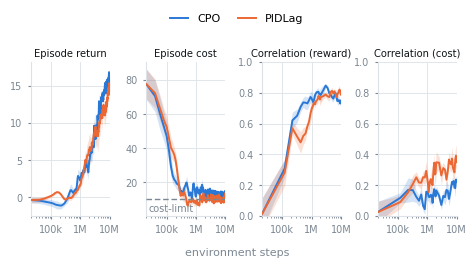

In [ ]:
plt.rcParams["figure.figsize"] = (16, 4)

COST_LIMIT = float(hist.cost_limit.dropna().iloc[0])


panels = [
    Panel("Metrics/EpRet",          "Episode return", smooth=2),
    Panel("Metrics/EpCost",         "Episode cost", smooth=2,
          hline=COST_LIMIT, hline_label="cost-limit"),
    # Correlations are framed on the full [0, 1] range. Early-training cost correlations do go
    # slightly negative, so the lower band edge is clipped at 0 in the first few evals.
    Panel("PooledMC/Correlation_r", "Correlation (reward)", smooth=2, ylim=(0.0, 1.0),
          yticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]),
    Panel("PooledMC/Correlation_c", "Correlation (cost)", smooth=2, ylim=(0.0, 1.0),
          yticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]),
]
series = {label_of(algo): (runs_for(hist, best.loc[algo]), SLOTS[i])
          for i, algo in enumerate(best.index)}

# Log x: the early phase -- cost falling to the limit, the correlation ramp -- happens in the first
# few hundred thousand steps and is a sliver on a linear axis. A log axis cannot contain 0
# (log 0 = -inf), so it starts at the first logged point: 20k steps, one epoch.
# wspace is relative to panel width, so it belongs at the call site: the toolkit default suits a
# page-width figure, and a 16in canvas has wide panels that need far less of a gap between them.
fig, axes = plot_panels(panels, series, xscale="log", xticks=[1e5, 1e6, 1e7],
                        xlim=(hist.TotalEnvSteps.min(), hist.TotalEnvSteps.max()), wspace=0.14)
save_fig(fig, "fig1_sweep_overview")